# Task 2

## Task 2a 2b 2c

In [1]:
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.sparse.csgraph import breadth_first_order
from scipy.special import logsumexp
import numpy as np
import itertools
import csv

In [39]:
class BinaryCLT:

    def __init__(self, data, root: int = None, alpha: float = 0.01):
        N, D = data.shape
        self.D = D
        self.data = data
        self.alpha = alpha
        self.root = root if root is not None else np.random.randint(D)

        # compute pairwise mutual information matrix (D x D)
        MI = np.zeros((D, D))
        self.MI = MI
        for i in range(D):
            for j in range(i + 1, D):
                mi_val = 0.0
                for xi in [0, 1]:
                    for xj in [0, 1]:
                        # raw joint and marginal counts
                        c_ij = np.sum((data[:, i] == xi) & (data[:, j] == xj))
                        c_i  = np.sum(data[:, i] == xi)
                        c_j  = np.sum(data[:, j] == xj)

                        # skip if joint count is zero (0 * log(0) = 0 by convention)
                        if c_ij == 0:
                            continue

                        p_ij = c_ij / N
                        p_i  = c_i  / N
                        p_j  = c_j  / N

                        mi_val += p_ij * (np.log(p_ij) - np.log(p_i) - np.log(p_j))

                MI[i, j] = MI[j, i] = mi_val


        # maximum spanning tree via negation trick
        mst = minimum_spanning_tree(-MI)

        # BFS from root returns parent array
        _, predecessors = breadth_first_order(mst, i_start=self.root,
                                            directed=False,
                                            return_predecessors=True)
        predecessors[self.root] = -1
        self.tree = predecessors

    def get_tree(self):
        return self.tree

    def get_log_params(self):
        data = self.data
        N, D = data.shape
        alpha = self.alpha
        tree = self.tree

        # initialize the D x 2 x 2 output array
        log_params = np.zeros((D, 2, 2))

        for i in range(D):
            parent = tree[i]

            if parent == -1:
                # root: use marginal probability, same for both j=0 and j=1
                for k in [0, 1]:
                    p = (2 * alpha + np.sum(data[:, i] == k)) / (4 * alpha + N)
                    log_params[i, 0, k] = np.log(p)
                    log_params[i, 1, k] = np.log(p)
            else:
                # non-root: conditional probability given parent value
                for j in [0, 1]:
                    for k in [0, 1]:
                        # count how many times Xi=k and Xparent=j co-occur
                        joint_count = np.sum((data[:, i] == k) & (data[:, parent] == j))
                        # count how many times Xparent=j occurs
                        parent_count = np.sum(data[:, parent] == j)
                        # Laplace-smoothed conditional (N cancels out)
                        p = (alpha + joint_count) / (2 * alpha + parent_count)
                        log_params[i, j, k] = np.log(p)

        return log_params

    def log_prob(self, x, exhaustive: bool = False):
        N, D = x.shape
        log_params = self.get_log_params()
        tree = self.tree
        lp = np.zeros((N, 1))

        if exhaustive:
            for n in range(N):
                query = x[n]
                # find indices of missing variables
                missing = np.where(np.isnan(query))[0]
                # find indices of observed variables
                observed = np.where(~np.isnan(query))[0]

                # enumerate all 2^|Z| combinations of missing variables
                joint_lps = []
                for values in itertools.product([0, 1], repeat=len(missing)):
                    # build the complete sample (y, z)
                    full = query.copy()
                    for idx, val in zip(missing, values):
                        full[idx] = val

                    # compute log p(y, z) by summing log-params along the tree
                    log_joint = 0.0
                    for i in range(D):
                        xi = int(full[i])
                        parent = tree[i]
                        if parent == -1:
                            # root: use marginal (j=0 and j=1 are the same)
                            log_joint += log_params[i, 0, xi]
                        else:
                            xp = int(full[parent])
                            log_joint += log_params[i, xp, xi]

                    joint_lps.append(log_joint)

                # sum all joint probabilities in log-space
                lp[n] = logsumexp(joint_lps)

        else:
            for n in range(N):
                query = x[n]

                # initialize messages: for each node, log-factor over its value
                # if observed: log(1) for correct value, log(0) for wrong value
                # if missing: log(1) for both values (uniform, no evidence)
                messages = np.zeros((D, 2))
                for i in range(D):
                    if np.isnan(query[i]):
                        messages[i] = [0.0, 0.0]       # missing: no constraint
                    else:
                        xi = int(query[i])
                        messages[i, 1 - xi] = -np.inf  # impossible value

                # process nodes from leaves to root (reverse BFS order)
                order = breadth_first_order(
                    minimum_spanning_tree(-self.MI),
                    i_start=self.root,
                    directed=False,
                    return_predecessors=False
                )

                for i in reversed(order):
                    parent = tree[i]
                    if parent == -1:
                        continue  # root handled separately

                    # marginalize Xi into parent message
                    for xp in [0, 1]:
                        # sum over xi: log p(xi | xp) + message(xi)
                        vals = [log_params[i, xp, xi] + messages[i, xi] for xi in [0, 1]]
                        messages[parent, xp] += logsumexp(vals)

                # compute final log prob at root
                root = self.root
                vals = [log_params[root, 0, xi] + messages[root, xi] for xi in [0, 1]]
                lp[n] = logsumexp(vals)

        return lp


    def sample(self, n_samples: int):
        # your code
        return samples

In [40]:
def load_dataset(filepath):
    with open(filepath, "r") as file:
        reader = csv.reader(file, delimiter=',')
        dataset = np.array(list(reader)).astype(float)
    return dataset

train = load_dataset("C:\\Users\\Utente\\Desktop\\Francesco\\Eindhoven\\TUE MSc Data Science & AI\\Generative AI\\GenAI-homework\\nltcs.train.data")
print("Shape:", train.shape)  # expected: (N, 16) per nltcs

Shape: (16181, 16)


## Check/visualiziation Tests

In [41]:
clt = BinaryCLT(train, root=0, alpha=0.01)
tree = clt.get_tree()

print("Tree:", tree)
print("Root is -1:", tree[0] == -1)              # root has to be -1
print("All parents valid:", all(p < 16 for p in tree if p != -1))  # no parent out of range
print("No cycles (unique parents):", len(set(tree[tree != -1])) == len(tree) - 1)

Tree: [-1  6  0  5 13  7  2  6  6  7 14 10  8 14 12 12]
Root is -1: True
All parents valid: True
No cycles (unique parents): False


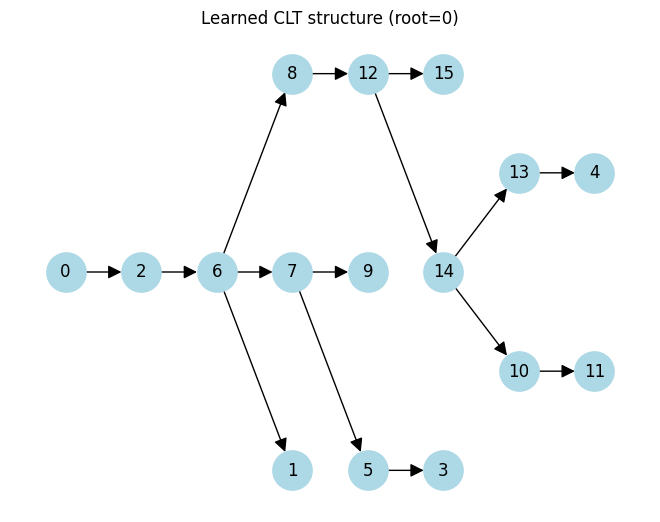

In [42]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
for i, parent in enumerate(tree):
    if parent != -1:
        G.add_edge(parent, i)

pos = nx.bfs_layout(G, start=clt.root)

nx.draw(G, pos, with_labels=True, node_color="lightblue",
        node_size=800, arrows=True, arrowsize=20)
plt.title("Learned CLT structure (root=0)")
plt.show()

In [43]:
log_params = clt.get_log_params()
print("Shape:", log_params.shape)  # atteso: (16, 2, 2)

Shape: (16, 2, 2)


In [44]:
print("Tutti <= 0:", np.all(log_params <= 0))  # log(p) <= 0 sempre
print("Nessun nan:", not np.any(np.isnan(log_params)))
print("Nessun -inf:", not np.any(np.isinf(log_params)))

Tutti <= 0: True
Nessun nan: True
Nessun -inf: True


In [45]:
# per ogni variabile i e ogni valore parent j, p(Xi=0|j) + p(Xi=1|j) = 1
probs = np.exp(log_params)
row_sums = probs.sum(axis=2)  # somma su k
print("Righe sommano a 1:\n", np.allclose(row_sums, 1.0))

Righe sommano a 1:
 True


In [46]:
# stampa N e D per verificare che il dataset sia caricato correttamente
print("N, D:", clt.data.shape)

# controlla i valori unici nel dataset (devono essere solo 0.0 e 1.0)
print("Valori unici:", np.unique(clt.data))

# stampa un calcolo intermedio per la root (X0)
i = clt.root
N = clt.data.shape[0]
alpha = clt.alpha
for k in [0, 1]:
    count = np.sum(clt.data[:, i] == k)
    p = (2 * alpha + count) / (4 * alpha + N)
    print(f"k={k}: count={count}, p={p:.4f}")

N, D: (16181, 16)
Valori unici: [0. 1.]
k=0: count=13816, p=0.8538
k=1: count=2365, p=0.1462


In [47]:
root = clt.root
print("Root duplice uguale:", np.allclose(log_params[root, 0, :], log_params[root, 1, :]))

Root duplice uguale: True


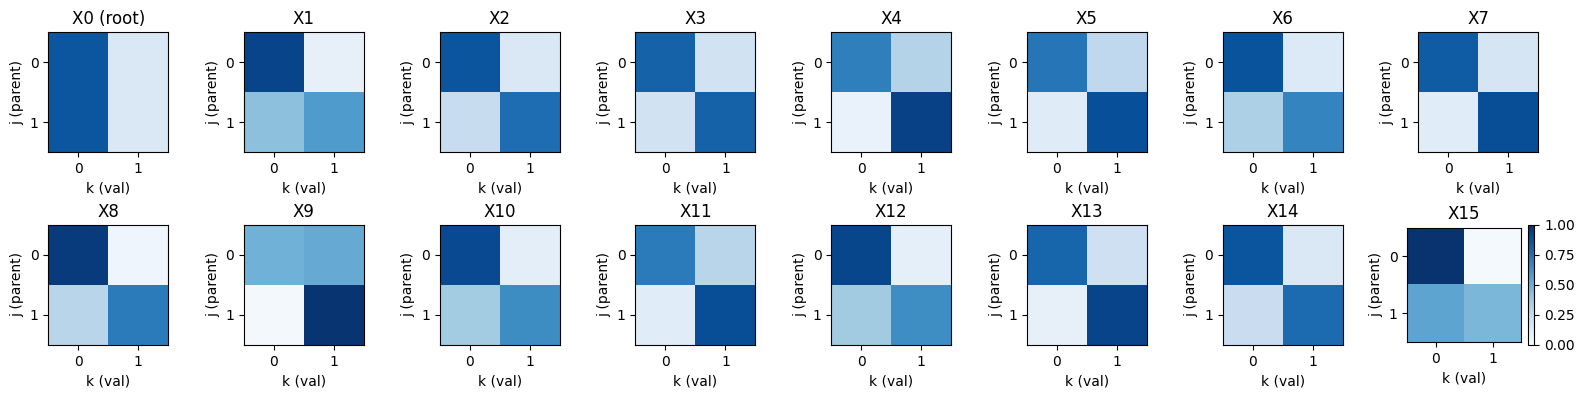

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 8, figsize=(16, 4))  # 16 variabili in griglia 2x8
axes = axes.flatten()

for i in range(clt.D):
    ax = axes[i]
    im = ax.imshow(np.exp(log_params[i]), vmin=0, vmax=1, cmap="Blues")
    ax.set_title(f"X{i}" + (" (root)" if i == clt.root else ""))
    ax.set_xlabel("k (val)")
    ax.set_ylabel("j (parent)")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

plt.colorbar(im, ax=axes[-1])
plt.tight_layout()
plt.show()

In [50]:
import time

# queries with increasing number of missing variables
x_test = np.array([
    [1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1.],  # 0 missing  → 2^0  = 1
    [np.nan, 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1.],  # 1 missing  → 2^1  = 2
    [np.nan, np.nan, np.nan, 1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1.],  # 3 missing  → 2^3  = 8
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0., 1., 1., 0., 1., 0., 1., 1., 0., 1.],  # 6 missing  → 2^6  = 64
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 1., 0., 1., 1., 0., 1.],  # 10 missing → 2^10 = 1024
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0., 1.],  # 14 missing → 2^14 = 16384
])

print(f"{'Query':<6} {'Missing':<10} {'Combinations':<15} {'Exhaustive':>12} {'Efficient':>12} {'Speedup':>10}")
print("-" * 70)

for i, query in enumerate(x_test):
    n_missing = int(np.sum(np.isnan(query)))
    n_combinations = 2 ** n_missing

    # exhaustive - single query
    q = query.reshape(1, -1)
    start = time.time()
    lp_ex = clt.log_prob(q, exhaustive=True)
    t_ex = time.time() - start

    # efficient - single query
    start = time.time()
    lp_ef = clt.log_prob(q, exhaustive=False)
    t_ef = time.time() - start

    speedup = t_ex / t_ef if t_ef > 0 else float('inf')
    match = "✓" if np.isclose(lp_ex, lp_ef) else "✗"

    print(f"  {i:<4} {n_missing:<10} {n_combinations:<15} {t_ex:>10.4f}s {t_ef:>10.4f}s {speedup:>8.1f}x  {match}")

Query  Missing    Combinations      Exhaustive    Efficient    Speedup
----------------------------------------------------------------------
  0    0          1                   0.0175s     0.0183s      1.0x  ✓
  1    1          2                   0.0127s     0.0144s      0.9x  ✓
  2    3          8                   0.0122s     0.0148s      0.8x  ✓
  3    6          64                  0.0134s     0.0169s      0.8x  ✓
  4    10         1024                0.0222s     0.0151s      1.5x  ✓
  5    14         16384               0.2186s     0.0209s     10.4x  ✓
